# 1. Project Introduction

## 1.1 Business Problem
The D2C personal-care company aims to reduce customer churn without applying blanket discounts to all customers.

Before developing predictive models or retention strategies, the business must understand:

• Customer purchasing behavior
• Engagement patterns
• Customer support interactions
• Campaign effectiveness
• Early indicators of churn

This analysis focuses on auditing the available data, exploring customer behavior, and identifying evidence-based churn-risk patterns.

## 1.2 Objective
The objectives of this analysis are:

1. Assess data quality and identify potential issues.
2. Validate dataset relationships and integration feasibility.
3. Create a customer-level analytical dataset.
4. Explore customer demographics and behavior.
5. Investigate churn-related patterns.
6. Formulate data-backed churn-risk hypotheses.
7. Provide business recommendations for future retention initiatives.

## 1.3 Datasets Used
| Dataset              | Description                   |
| -------------------- | ----------------------------- |
| customers            | Customer profile information  |
| orders               | Purchase transactions         |
| support_tickets      | Customer support interactions |
| web_events_snapshot  | Customer engagement activity  |
| intervention_history | Campaign history              |
| churn_labels         | Churn target variable         |


## 1.4 Prediction Context
Prediction Target:
Customer churn within the next 60 days.

Reference Snapshot Date:
2025-09-30

Important:
Only information available on or before the snapshot date should be used for analysis and future modeling activities.

## 1.5 Analysis Roadmap
Raw Datasets
      ↓
Data Quality Audit
      ↓
Join Validation
      ↓
Customer Master Dataset
      ↓
Exploratory Analysis
      ↓
Churn Investigation
      ↓
Business Insights

# 2. Data Loading & Initial Inspection

## 2.1 Import Libraries

In [163]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from pathlib import Path
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2.2 Load All Datasets

In [164]:
customers = pd.read_csv("../data/customers.csv")

orders = pd.read_csv(
    "../data/orders.csv",
    parse_dates=["order_date"]
)

tickets = pd.read_csv(
    "../data/support_tickets.csv"
)

web = pd.read_csv(
    "../data/web_events_snapshot.csv"
)

campaigns = pd.read_csv(
    "../data/intervention_history.csv"
)

churn = pd.read_csv(
    "../data/churn_labels.csv"
)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [165]:
from pathlib import Path

CHARTS_DIR = Path("../outputs/charts")
TABLES_DIR = Path("../outputs/tables")

CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 2.3 Dataset Shapes

In [166]:
dataset_shapes = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Support Tickets",
        "Web Events",
        "Campaign History",
        "Churn Labels"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        tickets.shape[0],
        web.shape[0],
        campaigns.shape[0],
        churn.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        tickets.shape[1],
        web.shape[1],
        campaigns.shape[1],
        churn.shape[1]
    ]
})

dataset_shapes

,Dataset,Rows,Columns
0,Customers,2400,9
1,Orders,10009,10
2,Support Tickets,1921,8
3,Web Events,2400,10
4,Campaign History,2400,5
5,Churn Labels,2400,4


### Observation

The project consists of six interconnected datasets covering customer profiles, purchase transactions, support interactions, engagement activity, campaign interventions, and churn outcomes.

## 2.4 Dataset Overview

In [167]:
dataset_overview = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "web_events_snapshot",
        "intervention_history",
        "churn_labels"
    ],
    "Description": [
        "Customer demographic and profile information",
        "Purchase transactions",
        "Customer support interactions",
        "Customer engagement activity",
        "Marketing campaign history",
        "Customer churn labels"
    ],
    "Primary Identifier": [
        "customer_id",
        "order_id",
        "ticket_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ]
})

dataset_overview

,Dataset,Description,Primary Identifier
0,customers,Customer demographic and profile information,customer_id
1,orders,Purchase transactions,order_id
2,support_tickets,Customer support interactions,ticket_id
3,web_events_snapshot,Customer engagement activity,customer_id
4,intervention_history,Marketing campaign history,customer_id
5,churn_labels,Customer churn labels,customer_id


### Observation

`customer_id` serves as the common integration key across datasets, enabling the creation of a unified customer-level analytical dataset for churn analysis.

## 2.5 First Look Samples

In [168]:
print("CUSTOMERS")
display(customers.head(3))

CUSTOMERS


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


In [169]:
print("ORDERS")
display(orders.head(3))

ORDERS


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


In [170]:
print("SUPPORT TICKETS")
display(tickets.head(3))

SUPPORT TICKETS


,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0


In [171]:
print("WEB EVENTS")
display(web.head(3))

WEB EVENTS


,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26


In [172]:
print("CAMPAIGN HISTORY")
display(campaigns.head(3))

CAMPAIGN HISTORY


,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


In [173]:
print("CHURN LABELS")
display(churn.head(3))

CHURN LABELS


,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train


### Observation

Initial inspection confirms the availability of demographic, behavioral, transactional, and churn-related information required for customer-level analysis.

# 3. Schema Understanding

## 3.1 Column Review

In [174]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web_events": web,
    "campaigns": campaigns,
    "churn_labels": churn
}

column_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Columns": [", ".join(df.columns) for df in datasets.values()]
})

column_summary

,Dataset,Columns
0,customers,"customer_id, signup_date, city_tier, age_group..."
1,orders,"order_id, customer_id, order_date, category, q..."
2,tickets,"ticket_id, customer_id, ticket_date, issue_typ..."
3,web_events,"customer_id, snapshot_date, sessions_30d, prod..."
4,campaigns,"customer_id, snapshot_date, last_campaign_rece..."
5,churn_labels,"customer_id, snapshot_date, churn_next_60d, split"


### Observation

The datasets contain customer profile, transactional, support, engagement, campaign, and churn-related attributes, providing a comprehensive view of customer behavior.

## 3.2 Data Types Review

In [175]:
dtype_summary = pd.concat(
    [
        pd.DataFrame({
            "Dataset": name,
            "Column": df.columns,
            "Data Type": df.dtypes.astype(str).values
        })
        for name, df in datasets.items()
    ],
    ignore_index=True
)

dtype_summary

,Dataset,Column,Data Type
0,customers,customer_id,str
1,customers,signup_date,str
2,customers,city_tier,str
3,customers,age_group,str
4,customers,acquisition_channel,str
5,customers,loyalty_tier,str
6,customers,preferred_category,str
7,customers,skin_type,str
8,customers,marketing_consent,str
9,orders,order_id,str


### Observation

Most columns have appropriate data types, although several date fields remain stored as strings and will be standardized during data preparation.

## 3.3 Primary Key Validation

In [176]:
primary_key_check = pd.DataFrame({
    "Dataset": [
        "customers",
        "orders",
        "support_tickets",
        "churn_labels"
    ],
    "Primary Key": [
        "customer_id",
        "order_id",
        "ticket_id",
        "customer_id"
    ],
    "Unique Values": [
        customers["customer_id"].nunique(),
        orders["order_id"].nunique(),
        tickets["ticket_id"].nunique(),
        churn["customer_id"].nunique()
    ],
    "Total Rows": [
        len(customers),
        len(orders),
        len(tickets),
        len(churn)
    ]
})

primary_key_check["Valid Primary Key"] = (
    primary_key_check["Unique Values"]
    ==
    primary_key_check["Total Rows"]
)

primary_key_check

,Dataset,Primary Key,Unique Values,Total Rows,Valid Primary Key
0,customers,customer_id,2400,2400,True
1,orders,order_id,10009,10009,True
2,support_tickets,ticket_id,1921,1921,True
3,churn_labels,customer_id,2400,2400,True


### Observation

All primary key columns are unique, indicating that records can be reliably identified within each dataset.

## 3.4 Foreign Key Relationships

In [177]:
foreign_key_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Foreign Key": [
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ]
})

foreign_key_summary

,Dataset,Foreign Key
0,orders,customer_id
1,support_tickets,customer_id
2,web_events,customer_id
3,campaigns,customer_id
4,churn_labels,customer_id


### Observation

The `customer_id` field serves as the common linkage across datasets, enabling customer-level integration and analysis.

## 3.5 Entity Relationship Overview

In [178]:
relationship_map = pd.DataFrame({
    "Parent Dataset": ["customers"] * 5,
    "Child Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Relationship": [
        "1 : Many",
        "1 : Many",
        "1 : 1",
        "1 : 1",
        "1 : 1"
    ]
})

relationship_map

,Parent Dataset,Child Dataset,Relationship
0,customers,orders,1 : Many
1,customers,support_tickets,1 : Many
2,customers,web_events,1 : 1
3,customers,campaigns,1 : 1
4,customers,churn_labels,1 : 1


### Observation

The customers dataset acts as the central entity, with transactional, support, engagement, campaign, and churn information linked through customer-level relationships.

### Analytical Grain

The final analytical dataset will be constructed at the customer level, where each row represents a unique customer. Transactional, support, engagement, and campaign records will be aggregated using `customer_id` before analysis.

# 4. Data Quality Audit

## 4.1 Missing Values

In [179]:
datasets = {
    "customers": customers,
    "orders": orders,
    "tickets": tickets,
    "web_events": web,
    "campaigns": campaigns,
    "churn_labels": churn
}

missing_summary = pd.concat(
    [
        pd.DataFrame({
            "Dataset": name,
            "Column": df.columns,
            "Missing Values": df.isna().sum().values,
            "Missing %": (df.isna().mean() * 100).round(2).values
        })
        for name, df in datasets.items()
    ],
    ignore_index=True
)

missing_summary = (
    missing_summary
    .query("`Missing Values` > 0")
    .sort_values("Missing %", ascending=False)
)

missing_summary

,Dataset,Column,Missing Values,Missing %
5,customers,loyalty_tier,1386,57.75
7,customers,skin_type,401,16.71
18,orders,rating,80,0.80


In [180]:
missing_summary.to_csv(
    TABLES_DIR / "missing_values_summary.csv",
    index=False
)

### Observation

Missing values are primarily concentrated in `loyalty_tier` (57.75%) and `skin_type` (16.71%), while missing ratings are minimal (0.80%). These fields will require appropriate treatment before analysis and modeling.

## 4.2 Duplicate Records

In [181]:
duplicate_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Duplicate Rows": [
        df.duplicated().sum()
        for df in datasets.values()
    ]
})

duplicate_summary

,Dataset,Duplicate Rows
0,customers,0
1,orders,0
2,tickets,0
3,web_events,0
4,campaigns,0
5,churn_labels,0


### Observation

No exact duplicate records were identified across any dataset, indicating good record-level integrity.

In [182]:
duplicate_like_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "tickets"
    ],
    "Duplicate-like Records": [
        orders.duplicated(
            subset=["customer_id","order_date","category"]
        ).sum(),
        tickets.duplicated(
            subset=["customer_id","ticket_date","issue_type"]
        ).sum()
    ]
})

duplicate_like_summary

,Dataset,Duplicate-like Records
0,orders,26
1,tickets,0


In [183]:
duplicate_summary.to_csv(
    TABLES_DIR / "duplicate_records_summary.csv",
    index=False
)

### Observation

A small number of duplicate-like order records (26) were identified, potentially reflecting repeated purchases rather than true duplication. No duplicate-like support tickets were found.

## 4.3 Invalid Values

In [184]:
# 4.3.1 Quantity Validation
quantity_validation = pd.DataFrame({
    "Validation Rule": ["Quantity <= 0"],
    "Invalid Records": [
        (orders["quantity"] <= 0).sum()
    ]
})

quantity_validation

,Validation Rule,Invalid Records
0,Quantity <= 0,0


In [185]:
# 4.3.2 DIscount Validation
discount_validation = pd.DataFrame({
    "Validation Rule": [
        "Discount < 0",
        "Discount > 1"
    ],
    "Invalid Records": [
        (orders["discount_pct"] < 0).sum(),
        (orders["discount_pct"] > 1).sum()
    ]
})

discount_validation

,Validation Rule,Invalid Records
0,Discount < 0,0
1,Discount > 1,0


In [186]:
# 4.3.3 Rating Validation
rating_validation = pd.DataFrame({
    "Validation Rule": [
        "Rating < 1",
        "Rating > 5"
    ],
    "Invalid Records": [
        (orders["rating"] < 1).sum(),
        (orders["rating"] > 5).sum()
    ]
})

rating_validation

,Validation Rule,Invalid Records
0,Rating < 1,0
1,Rating > 5,0


In [187]:
# 4.3.4 Sentiment Validation
sentiment_validation = pd.DataFrame({
    "Validation Rule": [
        "Sentiment < -1",
        "Sentiment > 1"
    ],
    "Invalid Records": [
        (tickets["sentiment_score"] < -1).sum(),
        (tickets["sentiment_score"] > 1).sum()
    ]
})

sentiment_validation

,Validation Rule,Invalid Records
0,Sentiment < -1,0
1,Sentiment > 1,0


In [188]:
# 4.3.5 Consolidated Validation Summary
validation_summary = pd.DataFrame({
    "Check": [
        "Quantity",
        "Discount",
        "Rating",
        "Sentiment"
    ],
    "Invalid Records": [
        (orders["quantity"] <= 0).sum(),
        ((orders["discount_pct"] < 0) | (orders["discount_pct"] > 1)).sum(),
        ((orders["rating"] < 1) | (orders["rating"] > 5)).sum(),
        ((tickets["sentiment_score"] < -1) | (tickets["sentiment_score"] > 1)).sum()
    ]
})

validation_summary

,Check,Invalid Records
0,Quantity,0
1,Discount,0
2,Rating,0
3,Sentiment,0


In [189]:
validation_summary.to_csv(
    TABLES_DIR / "invalid_values_summary.csv",
    index=False
)

### Observation
No invalid values were identified in the validated fields. Order quantities, discount percentages, ratings, and sentiment scores all fall within their expected business-defined ranges.

### Business Interpretation
The absence of invalid values indicates good data integrity for key transactional and customer experience variables, reducing the need for corrective data cleaning before analysis.

## 4.4 Outlier Assessment

In [190]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs/charts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

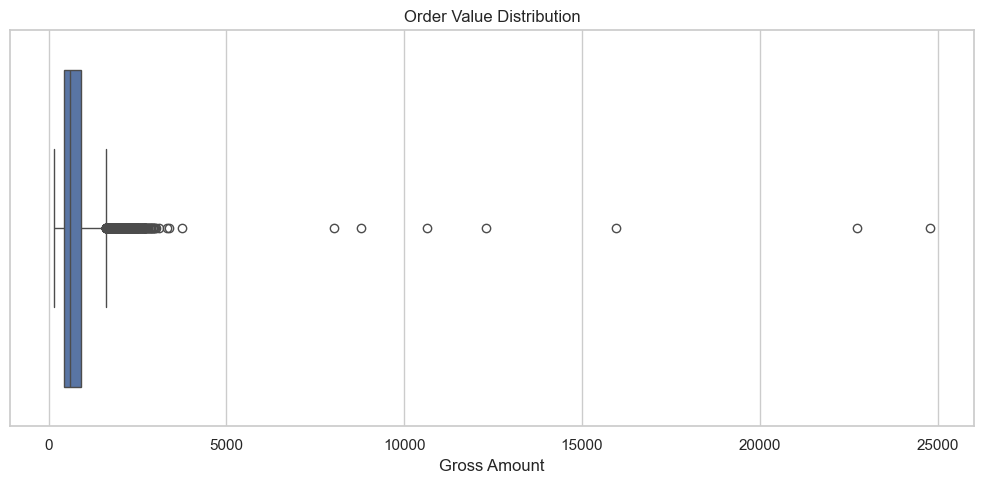

In [191]:
# 4.4.1 Order Value Distribution
plt.figure(figsize=(10,5))

sns.boxplot(
    x=orders["gross_amount"]
)

plt.title("Order Value Distribution")
plt.xlabel("Gross Amount")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "order_value_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

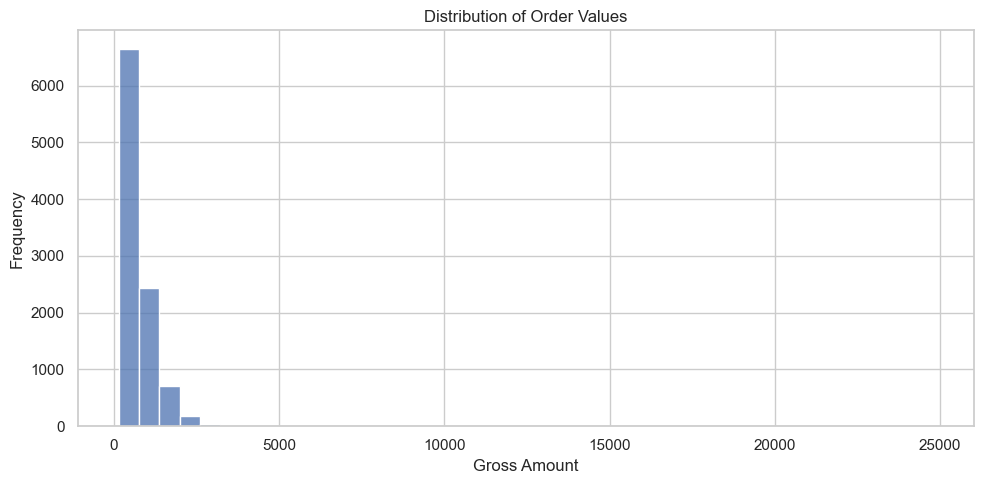

In [192]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["gross_amount"],
    bins=40)
plt.title("Distribution of Order Values")
plt.xlabel("Gross Amount")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "order_value_histogram.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [193]:
# 4.2.1 IQR Analysis
Q1 = orders["gross_amount"].quantile(0.25)
Q3 = orders["gross_amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = orders[
    (orders["gross_amount"] < lower_bound) |
    (orders["gross_amount"] > upper_bound)
]

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Records"
    ],
    "Value": [
        round(Q1,2),
        round(Q3,2),
        round(IQR,2),
        round(lower_bound,2),
        round(upper_bound,2),
        len(outliers)
    ]
})

outlier_summary

,Metric,Value
0,Q1,432.85
1,Q3,907.43
2,IQR,474.58
3,Lower Bound,-279.02
4,Upper Bound,1619.30
5,Outlier Records,536.00


In [194]:
order_value_stats = pd.DataFrame({
    "Metric": [
        "Minimum",
        "Average",
        "Median",
        "Maximum"
    ],
    "Value": [
        round(orders["gross_amount"].min(),2),
        round(orders["gross_amount"].mean(),2),
        round(orders["gross_amount"].median(),2),
        round(orders["gross_amount"].max(),2)
    ]
})

order_value_stats

,Metric,Value
0,Minimum,149.00
1,Average,743.90
2,Median,597.06
3,Maximum,24789.38


In [195]:
# 4.4.3 Business Impact
outlier_impact = pd.DataFrame({
    "Metric": [
        "Total Orders",
        "Outlier Orders",
        "Outlier Percentage"
    ],
    "Value": [
        len(orders),
        len(outliers),
        round((len(outliers) / len(orders)) * 100, 2)
    ]
})

outlier_impact

,Metric,Value
0,Total Orders,10009.00
1,Outlier Orders,536.00
2,Outlier Percentage,5.36


In [196]:
outlier_summary.to_csv(
    TABLES_DIR / "outlier_analysis.csv",
    index=False
)

### Observation

Order values exhibit a right-skewed distribution, with 536 transactions (5.36%) identified as potential outliers. While the average order value is ₹743.90, the maximum transaction reaches ₹24,789.38, indicating the presence of a small number of exceptionally high-value purchases.
### Business Impact

These outliers are likely to represent genuine high-value customer purchases rather than data errors. They should be retained for business analysis but may require robust scaling or transformation during future modeling to reduce their influence on statistical measures.

## 4.5 Join Integrity Validation

In [197]:
## 4.5.1 Orphan Record Check
customer_ids = set(customers["customer_id"])

join_validation = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Records": [
        len(orders),
        len(tickets),
        len(web),
        len(campaigns),
        len(churn)
    ],
    "Unique Customer IDs": [
        orders["customer_id"].nunique(),
        tickets["customer_id"].nunique(),
        web["customer_id"].nunique(),
        campaigns["customer_id"].nunique(),
        churn["customer_id"].nunique()
    ],
    "Orphan Customer IDs": [
        (~orders["customer_id"].isin(customer_ids)).sum(),
        (~tickets["customer_id"].isin(customer_ids)).sum(),
        (~web["customer_id"].isin(customer_ids)).sum(),
        (~campaigns["customer_id"].isin(customer_ids)).sum(),
        (~churn["customer_id"].isin(customer_ids)).sum()
    ]
})

join_validation

,Dataset,Records,Unique Customer IDs,Orphan Customer IDs
0,orders,10009,2400,0
1,support_tickets,1921,1247,0
2,web_events,2400,2400,0
3,campaigns,2400,2400,0
4,churn_labels,2400,2400,0


### Observation

No orphan customer records were identified across any dataset, indicating strong referential integrity and reliable dataset linkage through `customer_id`.

In [198]:
#  4.5.2 Merge Feasibility Assessment

merge_feasibility = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Join Key": [
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id",
        "customer_id"
    ],
    "Recommended Join": [
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN",
        "LEFT JOIN"
    ]
})

merge_feasibility

,Dataset,Join Key,Recommended Join
0,orders,customer_id,LEFT JOIN
1,support_tickets,customer_id,LEFT JOIN
2,web_events,customer_id,LEFT JOIN
3,campaigns,customer_id,LEFT JOIN
4,churn_labels,customer_id,LEFT JOIN


### Observation

All datasets can be safely integrated using `customer_id`, with a customer-level LEFT JOIN strategy preserving the complete customer base during analysis.

In [199]:
customer_coverage = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets",
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Customer Coverage %": [
        round(
            orders["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            tickets["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            web["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            campaigns["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        ),
        round(
            churn["customer_id"].nunique() /
            customers["customer_id"].nunique() * 100,
            2
        )
    ]
})

customer_coverage

,Dataset,Customer Coverage %
0,orders,100.00
1,support_tickets,51.96
2,web_events,100.00
3,campaigns,100.00
4,churn_labels,100.00


In [200]:
join_validation.to_csv(
    TABLES_DIR / "join_integrity_validation.csv",
    index=False
)

### Observation

Orders, web events, campaigns, and churn labels provide complete customer coverage (100%), while support tickets cover 51.96% of customers, indicating that support interactions occur for a subset of the customer base.

### Business Interpretation

The absence of orphan records confirms that customer-level dataset integration can be performed without record loss. The lower coverage of support tickets reflects normal business behavior rather than a data quality issue, as not all customers require support interactions.

## 4.6 Date Consistency Analysis

In [201]:
# 4.6.1 Snapshot Validation
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

tickets["ticket_date"] = pd.to_datetime(tickets["ticket_date"])

web["snapshot_date"] = pd.to_datetime(web["snapshot_date"])

campaigns["snapshot_date"] = pd.to_datetime(campaigns["snapshot_date"])

churn["snapshot_date"] = pd.to_datetime(churn["snapshot_date"])

In [202]:
snapshot_validation = pd.DataFrame({
    "Dataset": [
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Minimum Snapshot Date": [
        web["snapshot_date"].min(),
        campaigns["snapshot_date"].min(),
        churn["snapshot_date"].min()
    ],
    "Maximum Snapshot Date": [
        web["snapshot_date"].max(),
        campaigns["snapshot_date"].max(),
        churn["snapshot_date"].max()
    ]
})

snapshot_validation

,Dataset,Minimum Snapshot Date,Maximum Snapshot Date
0,web_events,2025-09-30,2025-09-30
1,campaigns,2025-09-30,2025-09-30
2,churn_labels,2025-09-30,2025-09-30


In [203]:
# 4.6.2 Post- snapshot Records
snapshot_date = pd.Timestamp("2025-09-30")

In [204]:
# Orders After Snapshot
post_snapshot_orders = (
    orders["order_date"] > snapshot_date
).sum()

post_snapshot_orders

np.int64(1872)

In [205]:
# Tickets After Snapshot
post_snapshot_tickets = (
    tickets["ticket_date"] > snapshot_date
).sum()

post_snapshot_tickets

np.int64(0)

In [206]:
# Consolidate Summary
future_order_pct = round(
    (post_snapshot_orders / len(orders)) * 100,
    2
)

pd.DataFrame({
    "Metric": [
        "Post-Snapshot Orders",
        "Percentage of Total Orders"
    ],
    "Value": [
        post_snapshot_orders,
        f"{future_order_pct}%"
    ]
})

,Metric,Value
0,Post-Snapshot Orders,1872
1,Percentage of Total Orders,18.7%


In [207]:
date_range_summary = pd.DataFrame({
    "Dataset": [
        "orders",
        "support_tickets"
    ],
    "Minimum Date": [
        orders["order_date"].min(),
        tickets["ticket_date"].min()
    ],
    "Maximum Date": [
        orders["order_date"].max(),
        tickets["ticket_date"].max()
    ]
})

date_range_summary

,Dataset,Minimum Date,Maximum Date
0,orders,2024-01-09,2025-11-29
1,support_tickets,2024-01-13,2025-09-30


In [208]:
date_consistency_summary.to_csv(
    TABLES_DIR / "date_consistency_summary.csv",
    index=False
)

### Observation

All snapshot-based datasets are consistently aligned to the reference date (2025-09-30). However, 1,872 order records occur after the snapshot date, indicating the presence of future transactional information within the raw data.
### Business Interpretation

While the data is temporally consistent overall, post-snapshot orders represent future information relative to the churn prediction reference date and must be excluded from feature engineering to prevent data leakage.

## 4.7 Leakage Risk Assessment

In [209]:
#  4.7.1 Future Orders
future_orders = pd.DataFrame({
    "Leakage Source": ["Orders After Snapshot Date"],
    "Affected Records": [post_snapshot_orders]
})

future_orders

# 4.7.2 Future Tickets
future_tickets = pd.DataFrame({
    "Leakage Source": ["Tickets After Snapshot Date"],
    "Affected Records": [post_snapshot_tickets]
})

future_tickets

# 4.7.3 Future Campaign Information
future_campaigns = pd.DataFrame({
    "Dataset": [
        "web_events",
        "campaigns",
        "churn_labels"
    ],
    "Snapshot Date": [
        web["snapshot_date"].max(),
        campaigns["snapshot_date"].max(),
        churn["snapshot_date"].max()
    ]
})

future_campaigns

,Dataset,Snapshot Date
0,web_events,2025-09-30
1,campaigns,2025-09-30
2,churn_labels,2025-09-30


In [210]:
# Leakage_summary 
leakage_summary = pd.DataFrame({
    "Feature Source": [
        "Orders",
        "Support Tickets",
        "Campaign History",
        "Web Events"
    ],
    "Leakage Risk": [
        "High",
        "Low",
        "Low",
        "Low"
    ],
    "Reason": [
        "Contains post-snapshot transactions",
        "No post-snapshot records detected",
        "Aligned to snapshot date",
        "Aligned to snapshot date"
    ]
})

leakage_summary

,Feature Source,Leakage Risk,Reason
0,Orders,High,Contains post-snapshot transactions
1,Support Tickets,Low,No post-snapshot records detected
2,Campaign History,Low,Aligned to snapshot date
3,Web Events,Low,Aligned to snapshot date


In [211]:
leakage_summary.to_csv(
    TABLES_DIR / "leakage_risk_assessment.csv",
    index=False
)

### Observation

Snapshot-based datasets are consistently aligned to the reference date (2025-09-30). The primary leakage risk originates from order data, where post-snapshot transactions are present, while support tickets, campaign history, and web activity remain temporally consistent with the snapshot period.
### Business Interpretation

Future order records should be excluded from feature creation and modeling activities to prevent data leakage. Maintaining strict snapshot-date filtering will ensure that churn analysis and future predictive models reflect information that would have been available at the time of prediction.

# 5. Customer Master Dataset Construction

## 5.1 Aggregation Strategy

The raw datasets operate at different levels of granularity. To enable customer-level analysis, transactional, support, engagement, and campaign data are aggregated using `customer_id`.

The resulting customer master dataset will contain one record per customer and serve as the foundation for exploratory analysis and churn investigation.

In [212]:
# 5.2 Order Features
snapshot_date = pd.Timestamp("2025-09-30")

orders_pre_snapshot = orders[
    orders["order_date"] <= snapshot_date
].copy()

order_features = (
    orders_pre_snapshot
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "count"),
        total_spend=("gross_amount", "sum"),
        avg_order_value=("gross_amount", "mean"),
        avg_discount_pct=("discount_pct", "mean"),
        return_rate=("returned", "mean"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

order_features.head()

,customer_id,total_orders,total_spend,avg_order_value,avg_discount_pct,return_rate,avg_rating
0,CUST00001,6,2955.57,492.5950,0.363333,0.166667,3.333333
1,CUST00002,1,581.00,581.0000,0.230000,0.000000,4.000000
2,CUST00003,1,649.98,649.9800,0.470000,0.000000,2.000000
3,CUST00004,1,1604.04,1604.0400,0.160000,0.000000,2.000000
4,CUST00005,4,2550.91,637.7275,0.442500,0.000000,2.000000


In [213]:
order_features.to_csv(
    TABLES_DIR / "order_features.csv",
    index=False
)

In [214]:
# 5.3 Support Features
support_features = (
    tickets
    .groupby("customer_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        avg_sentiment=("sentiment_score", "mean"),
        reopen_rate=("reopened", "mean")
    )
    .reset_index()
)

support_features.head()

,customer_id,ticket_count,avg_resolution_hours,avg_sentiment,reopen_rate
0,CUST00001,2,4.35,0.14,0.0
1,CUST00002,1,1.00,0.00,0.0
2,CUST00005,1,37.70,-1.00,0.0
3,CUST00006,2,17.60,-0.68,0.5
4,CUST00008,1,6.00,0.08,0.0


In [215]:
support_features.to_csv(
    TABLES_DIR / "support_features.csv",
    index=False
)

In [216]:
# 5.4 Web Features
web_features = web.copy()

web_features.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [217]:
# 5.5 Campaign Features
campaign_features = campaigns.copy()

campaign_features.head()

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [218]:
# 5.6 Merge Logic
customer_master = (
    customers
    .merge(order_features,
           on="customer_id",
           how="left")
    .merge(support_features,
           on="customer_id",
           how="left")
    .merge(web_features,
           on="customer_id",
           how="left")
    .merge(campaign_features,
           on="customer_id",
           how="left")
    .merge(churn,
           on="customer_id",
           how="left")
)

customer_master.shape

(2400, 35)

In [219]:
customer_master.to_csv(
    TABLES_DIR / "customer_master_dataset.csv",
    index=False
)

In [220]:
# Feature Table Schema
schema_summary = pd.DataFrame({
    "Column": customer_master.columns,
    "Data Type": customer_master.dtypes.astype(str).values
})

schema_summary

,Column,Data Type
0,customer_id,str
1,signup_date,datetime64[us]
2,city_tier,str
3,age_group,str
4,acquisition_channel,str
5,loyalty_tier,str
6,preferred_category,str
7,skin_type,str
8,marketing_consent,str
9,total_orders,int64


In [221]:
schema_summary.to_csv(
    TABLES_DIR / "customer_master_schema.csv",
    index=False
)

In [223]:
feature_summary = pd.DataFrame({
    "Metric": [
        "Customers",
        "Features"
    ],
    "Value": [
        customer_master.shape[0],
        customer_master.shape[1]
    ]
})

feature_summary

feature_summary.to_csv(
    TABLES_DIR / "customer_master_summary.csv",
    index=False
)

# 6. Exploratry Data Analysis
## 6.1 Customer Demographics

In [240]:
# Age Distribution
age_distribution = (
    customer_master["age_group"]
    .value_counts(dropna=False)
    .reset_index()
)

age_distribution.columns = [
    "Age Group",
    "Customer Count"
]

age_distribution

,Age Group,Customer Count
0,25-34,1045
1,18-24,560
2,35-44,534
3,45+,261


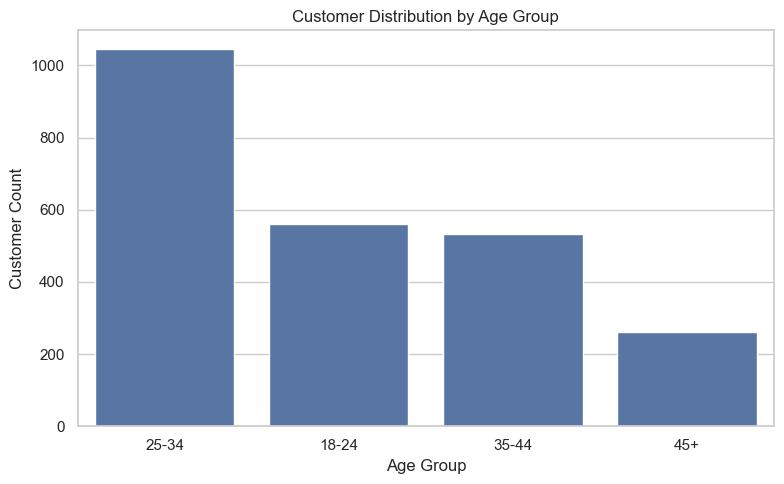

In [248]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_master,
    x="age_group",
    order=customer_master["age_group"].value_counts().index
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.show()

In [249]:
# 6.1.2 Acquisition Channel
acquisition_distribution = (
    customer_master["acquisition_channel"]
    .value_counts(dropna=False)
    .reset_index()
)

acquisition_distribution.columns = [
    "Acquisition Channel",
    "Customer Count"
]

acquisition_distribution

,Acquisition Channel,Customer Count
0,Instagram,517
1,Google Search,466
2,Marketplace,456
3,Referral,396
4,Organic,334
5,Influencer,231


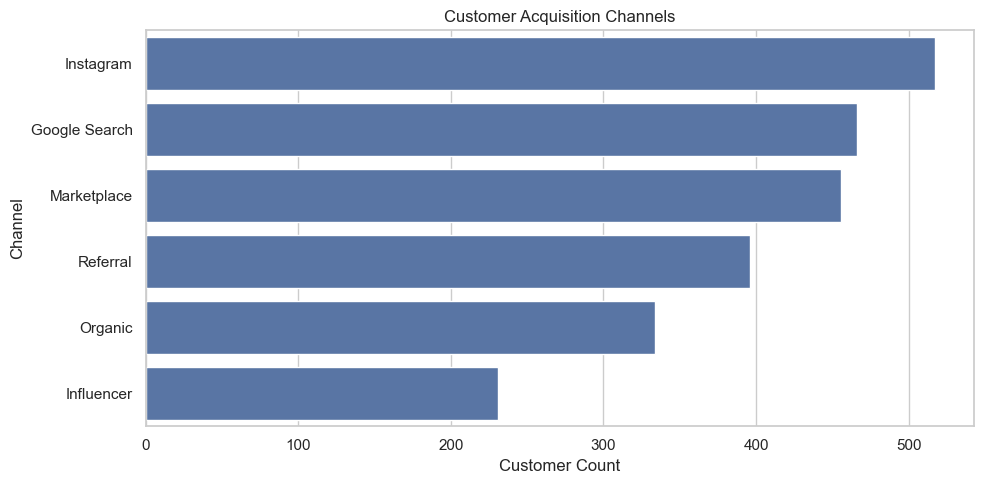

In [250]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=customer_master,
    y="acquisition_channel",
    order=customer_master["acquisition_channel"]
            .value_counts()
            .index
)

plt.title("Customer Acquisition Channels")
plt.xlabel("Customer Count")
plt.ylabel("Channel")

plt.tight_layout()
plt.show()

In [251]:
# 6.1.3 City Tier
city_tier_distribution = (
    customer_master["city_tier"]
    .value_counts(dropna=False)
    .reset_index()
)

city_tier_distribution.columns = [
    "City Tier",
    "Customer Count"
]

city_tier_distribution

,City Tier,Customer Count
0,Tier 1,1005
1,Tier 2,870
2,Tier 3,525


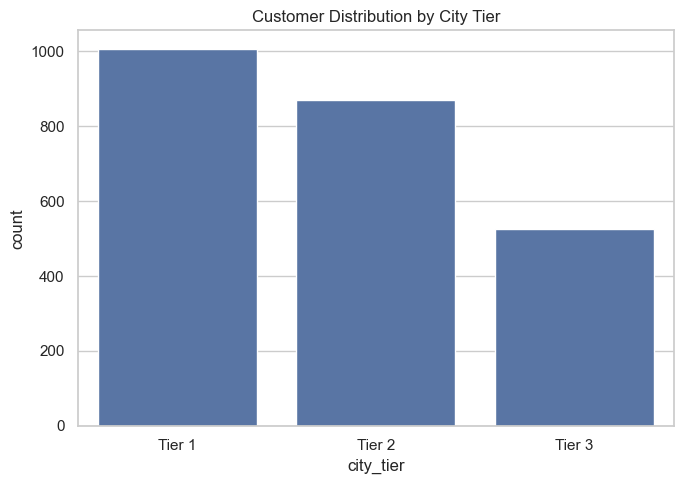

In [252]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=customer_master,
    x="city_tier",
    order=customer_master["city_tier"]
            .value_counts()
            .index
)

plt.title("Customer Distribution by City Tier")

plt.tight_layout()

plt.show()

In [253]:
# 6.1.4 Loyalty Tier
loyalty_distribution = (
    customer_master["loyalty_tier"]
    .fillna("Not Enrolled")
    .value_counts()
    .reset_index()
)

loyalty_distribution.columns = [
    "Loyalty Tier",
    "Customer Count"
]

loyalty_distribution


,Loyalty Tier,Customer Count
0,Not Enrolled,1386
1,Silver,590
2,Gold,319
3,Platinum,105


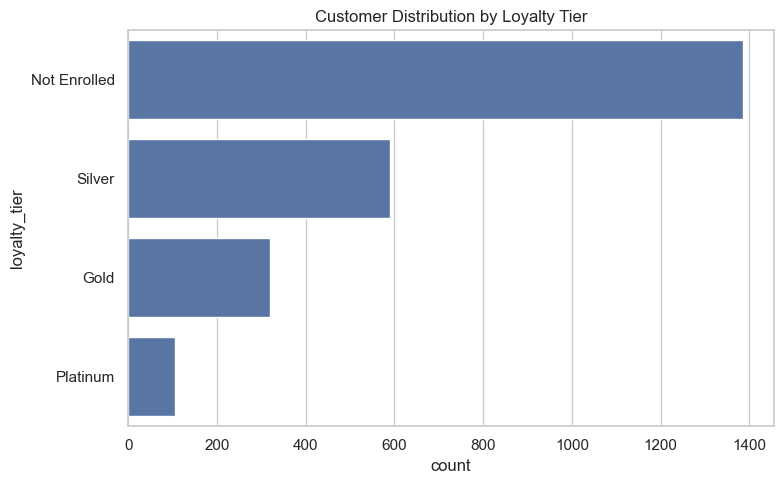

In [254]:
plt.figure(figsize=(8,5))

sns.countplot(
    y=customer_master["loyalty_tier"]
      .fillna("Not Enrolled"),
    order=customer_master["loyalty_tier"]
            .fillna("Not Enrolled")
            .value_counts()
            .index
)

plt.title("Customer Distribution by Loyalty Tier")

plt.tight_layout()

plt.show()

### Observation

The customer base is concentrated in the 25–34 age group, Tier 1 and Tier 2 cities, and digital acquisition channels such as Instagram and Google Search. More than half of customers are not enrolled in the loyalty program, indicating significant potential for membership-driven engagement initiatives.
### Business Interpretation

The customer base is predominantly composed of digitally acquired young adults. The large proportion of non-enrolled customers suggests an opportunity to strengthen retention through loyalty program adoption and targeted customer engagement strategies.

## Order Behaviour

In [255]:
# Order Count
order_count_summary = customer_master[
    ["customer_id", "total_orders"]
].copy()

order_count_summary["total_orders"].describe()

count    2400.000000
mean        3.390417
std         2.383350
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        16.000000
Name: total_orders, dtype: float64

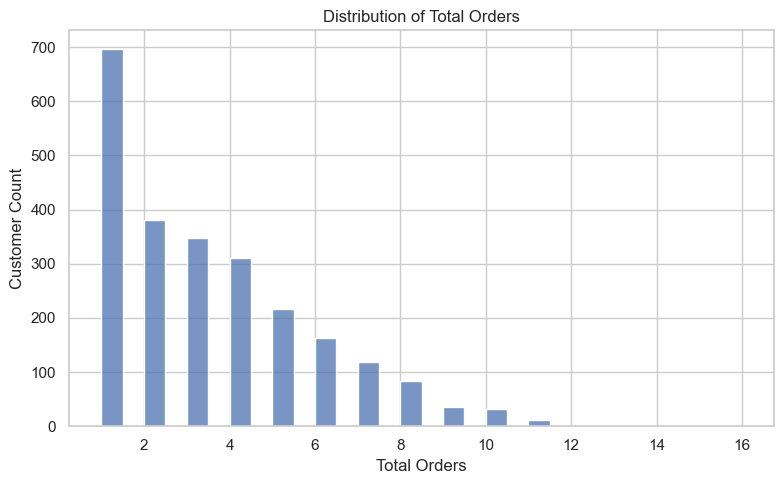

In [256]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["total_orders"],
    bins=30
)

plt.title("Distribution of Total Orders")
plt.xlabel("Total Orders")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "order_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [257]:
# 6.2.2 Purchase frequency
purchase_frequency_summary = pd.DataFrame({
    "Metric": [
        "Average Orders",
        "Median Orders",
        "Maximum Orders"
    ],
    "Value": [
        round(customer_master["total_orders"].mean(), 2),
        round(customer_master["total_orders"].median(), 2),
        customer_master["total_orders"].max()
    ]
})

purchase_frequency_summary

,Metric,Value
0,Average Orders,3.39
1,Median Orders,3.00
2,Maximum Orders,16.00


In [258]:
# 6.2.3 Category Diversity

category_diversity = (
    orders_pre_snapshot
    .groupby("customer_id")
    .agg(
        category_diversity=("category", "nunique")
    )
    .reset_index()
)

customer_master = customer_master.merge(
    category_diversity,
    on="customer_id",
    how="left"
)


In [259]:
category_diversity_summary = (
    customer_master["category_diversity"]
    .describe()
)

category_diversity_summary

count    2400.000000
mean        2.351250
std         1.260371
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: category_diversity, dtype: float64

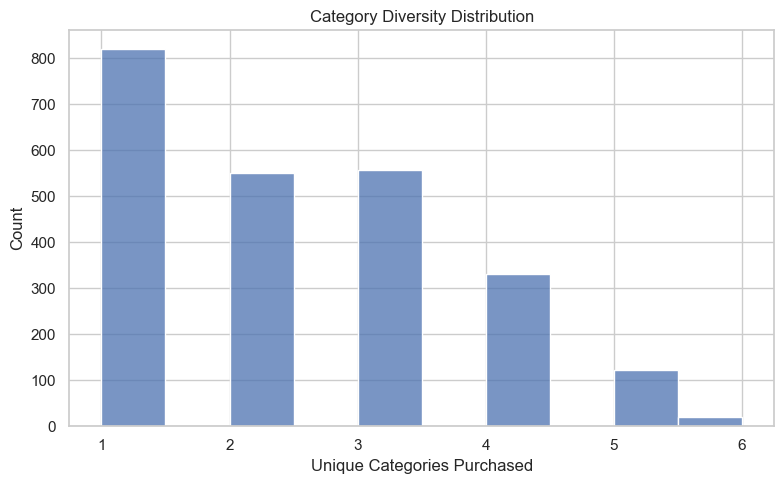

In [260]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["category_diversity"],
    bins=10
)

plt.title("Category Diversity Distribution")
plt.xlabel("Unique Categories Purchased")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "category_diversity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [261]:
# 6.2.4 Discount Usage
discount_usage_summary = pd.DataFrame({
    "Metric": [
        "Average Discount %",
        "Median Discount %",
        "Maximum Discount %"
    ],
    "Value": [
        round(customer_master["avg_discount_pct"].mean() * 100, 2),
        round(customer_master["avg_discount_pct"].median() * 100, 2),
        round(customer_master["avg_discount_pct"].max() * 100, 2)
    ]
})

discount_usage_summary

,Metric,Value
0,Average Discount %,28.07
1,Median Discount %,28.00
2,Maximum Discount %,64.00


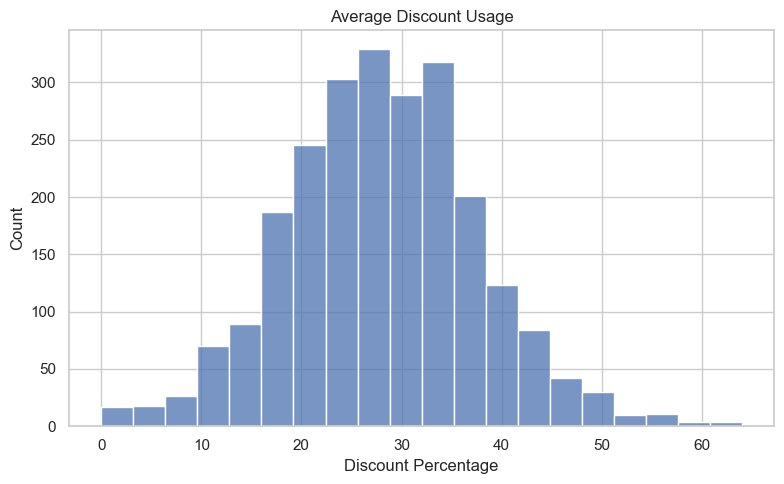

In [263]:
plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["avg_discount_pct"] * 100,
    bins=20
)

plt.title("Average Discount Usage")
plt.xlabel("Discount Percentage")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "discount_usage_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customer purchasing behavior is moderately repeat-driven, with customers placing an average of 3.39 orders and a median of 3 orders. Category diversity is relatively low (average 2.35 categories), suggesting that many customers purchase within a limited set of product categories. Discount usage is common across the customer base, with customers receiving an average discount of approximately 28%.
### Business Interpretation

The data suggests that repeat purchasing is established but category expansion opportunities remain. The widespread use of discounts indicates that promotional incentives may play an important role in customer purchasing decisions and should be further investigated as a potential churn-related factor.

## 6.3 Monetary Behaviour

In [265]:
# 6.3.1 Lifetime Revenue
revenue_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Average Revenue per Customer",
        "Median Revenue per Customer",
        "Maximum Customer Revenue"
    ],
    "Value": [
        round(customer_master["total_spend"].sum(), 2),
        round(customer_master["total_spend"].mean(), 2),
        round(customer_master["total_spend"].median(), 2),
        round(customer_master["total_spend"].max(), 2)
    ]
})

revenue_summary

,Metric,Value
0,Total Revenue,6119173.75
1,Average Revenue per Customer,2549.66
2,Median Revenue per Customer,2012.02
3,Maximum Customer Revenue,27215.92


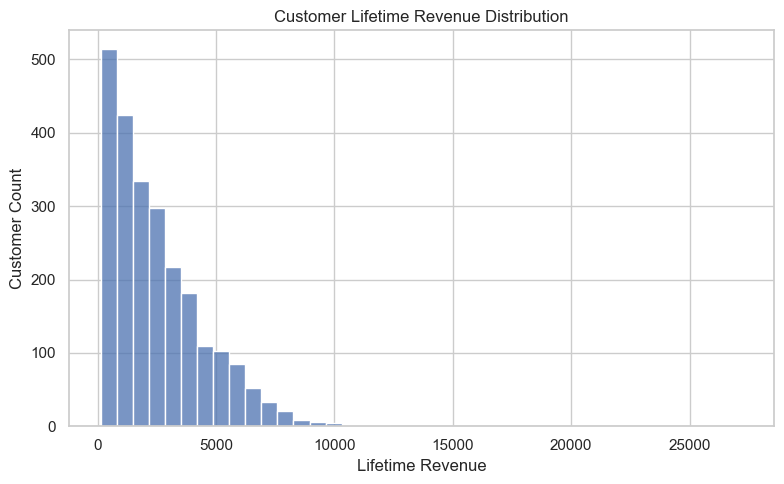

In [266]:
# 6.3.2 Revenue DIstribution

plt.figure(figsize=(8,5))

sns.histplot(
    customer_master["total_spend"],
    bins=40
)

plt.title("Customer Lifetime Revenue Distribution")
plt.xlabel("Lifetime Revenue")
plt.ylabel("Customer Count")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "lifetime_revenue_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [267]:
# 6.3.3 Average Order Value
aov_summary = pd.DataFrame({
    "Metric": [
        "Average Order Value",
        "Median Order Value",
        "Maximum Order Value"
    ],
    "Value": [
        round(customer_master["avg_order_value"].mean(), 2),
        round(customer_master["avg_order_value"].median(), 2),
        round(customer_master["avg_order_value"].max(), 2)
    ]
})

aov_summary

,Metric,Value
0,Average Order Value,753.60
1,Median Order Value,681.79
2,Maximum Order Value,8685.76


In [268]:
# 6.3.4 Revenue Concentration
customer_revenue = (
    customer_master
    .sort_values("total_spend", ascending=False)
)

top_10_pct = int(len(customer_revenue) * 0.10)

top_revenue_share = round(
    (
        customer_revenue.head(top_10_pct)["total_spend"].sum()
        /
        customer_revenue["total_spend"].sum()
    ) * 100,
    2
)

revenue_concentration = pd.DataFrame({
    "Metric": [
        "Top 10% Customers Revenue Share"
    ],
    "Value": [
        f"{top_revenue_share}%"
    ]
})

revenue_concentration

,Metric,Value
0,Top 10% Customers Revenue Share,27.64%


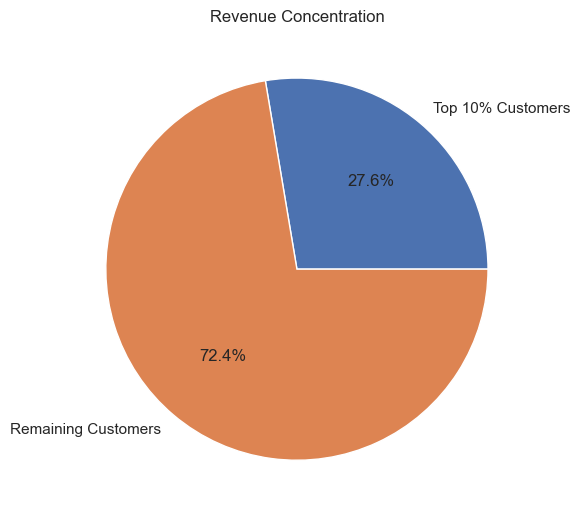

In [269]:
top_10_revenue = customer_revenue.head(top_10_pct)["total_spend"].sum()
remaining_revenue = customer_revenue.iloc[top_10_pct:]["total_spend"].sum()

revenue_share = pd.DataFrame({
    "Group": [
        "Top 10% Customers",
        "Remaining Customers"
    ],
    "Revenue": [
        top_10_revenue,
        remaining_revenue
    ]
})

plt.figure(figsize=(6,6))

plt.pie(
    revenue_share["Revenue"],
    labels=revenue_share["Group"],
    autopct="%1.1f%%"
)

plt.title("Revenue Concentration")

plt.tight_layout()

plt.savefig(
    CHARTS_DIR / "revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [270]:
customer_master["value_segment"] = pd.qcut(
    customer_master["total_spend"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Top Value"
    ]
)

value_segment_summary = (
    customer_master["value_segment"]
    .value_counts()
    .reset_index()
)

value_segment_summary.columns = [
    "Value Segment",
    "Customer Count"
]

value_segment_summary

,Value Segment,Customer Count
0,Low Value,600
1,Medium Value,600
2,High Value,600
3,Top Value,600


### Observation

Customer spending is moderately concentrated, with total revenue of ₹6.12 million and an average customer lifetime revenue of ₹2,549.66. The top 10% of customers contribute 27.64% of total revenue, indicating the presence of a valuable high-spending customer segment. Average order values remain relatively consistent, with a median of ₹681.79 and an average of ₹753.60.
### Business Interpretation

A relatively small group of high-value customers contributes a disproportionate share of revenue, making their retention strategically important. Retention initiatives should therefore prioritize protecting high-spending customers while encouraging lower-value customers to increase purchase frequency and category adoption.